<a href="https://colab.research.google.com/github/Saniya-Nawaz/Diabetes_prediction_ML/blob/main/Diabetes_prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print(df.shape)
print(df.columns.tolist())

(768, 9)
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
df.to_csv("diabetes.csv", index=False)

In [ ]:
import os
os.listdir()

['.config', 'diabetes.csv', 'sample_data']

In [ ]:
df = pd.read_csv("diabetes.csv")

1. Libraries Imported


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#Dataset Shape
print(df.shape)

(768, 9)


In [ ]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [ ]:
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [ ]:
#Statistical Summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


2. EDA

In [ ]:
#Missing Value Analysis
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

print(df[zero_columns].eq(0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
#Handling Invalid Zero Values
df[zero_columns] = df[zero_columns].replace(0, np.nan)

In [ ]:
for column in zero_columns:
    df[column] = df[column].fillna(df[column].median())

In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
#Duplicate Value Analysis
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 0


In [ ]:
df = df.drop_duplicates()

In [ ]:
print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


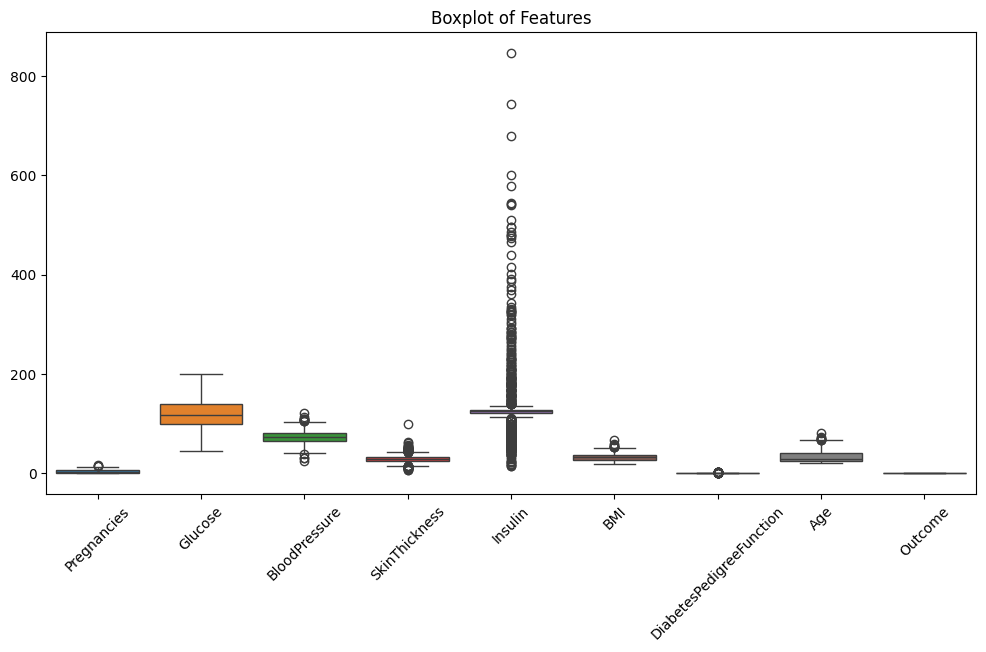

In [ ]:
#Outlier Analysis
plt.figure(figsize=(12, 6))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

In [ ]:
#Feature and Target Separation
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
#Encoding
print(X.dtypes)

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object


In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. ML Agorithms

### *1. Logistic Regression*

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

### *2. Decision Tree Classifier*

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

### *3. Random Forest Classifier*

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

### *4. K-Nearest Neighbors (KNN)*

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

### *5. Support Vector Machine (SVM)*

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    random_state=42
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

### *6. Naive Bayes*

In [ ]:
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()

naive_bayes.fit(X_train, y_train)

y_pred_nb = naive_bayes.predict(X_test)

### *7. Gradient Boosting*

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

gradient_boosting.fit(X_train, y_train)

y_pred_gb = gradient_boosting.predict(X_test)

### *8. AdaBoost*

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

adaboost = AdaBoostClassifier(
    random_state=42
)

adaboost.fit(X_train, y_train)

y_pred_ab = adaboost.predict(X_test)

# 4.Evaluation and Comparison


### Accuracy, Precision, Recall, F1 Score



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
import numpy as np


model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb,
    "Gradient Boosting": y_pred_gb,
    "AdaBoost": y_pred_ab
}

results = []

for name, y_pred in model_predictions.items():

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Display results
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.707792,0.698892,0.707792,0.700802
1,Decision Tree,0.681818,0.673403,0.681818,0.676172
2,Random Forest,0.779221,0.774498,0.779221,0.773213
3,KNN,0.753247,0.749660,0.753247,0.750921
4,SVM,0.740260,0.733735,0.740260,0.734865
5,Naive Bayes,0.701299,0.709892,0.701299,0.704540
6,Gradient Boosting,0.759740,0.753890,0.759740,0.753992
7,AdaBoost,0.746753,0.741050,0.746753,0.742259


###Confusion Matrix

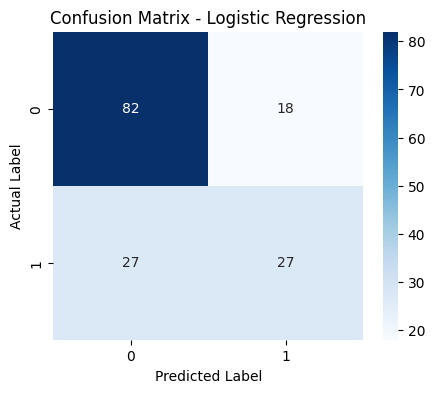

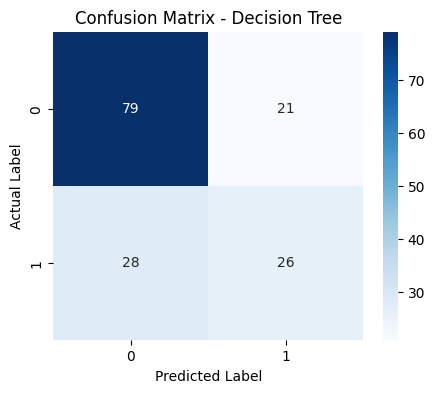

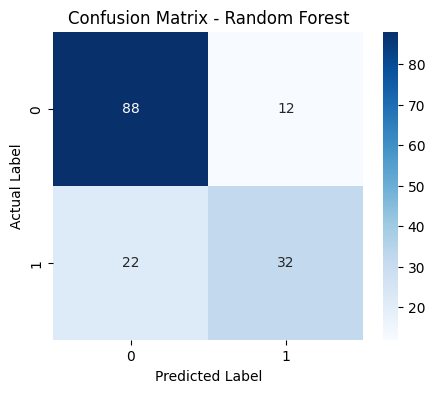

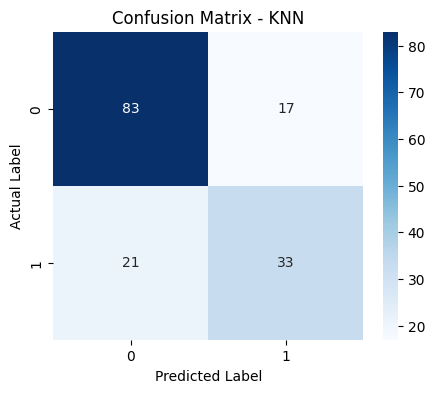

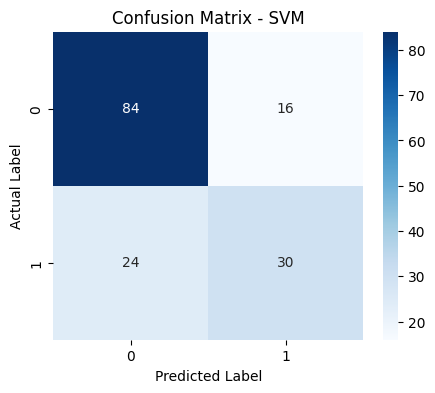

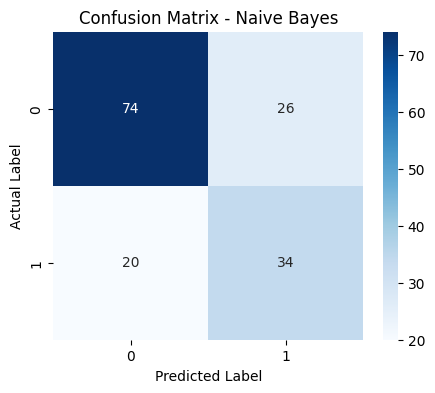

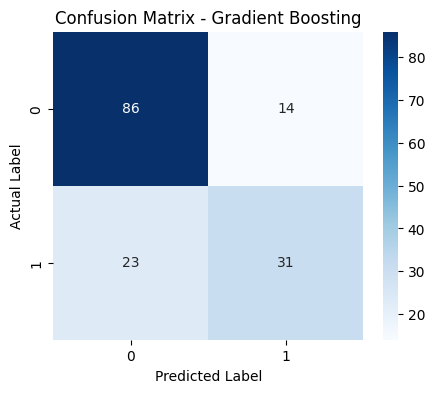

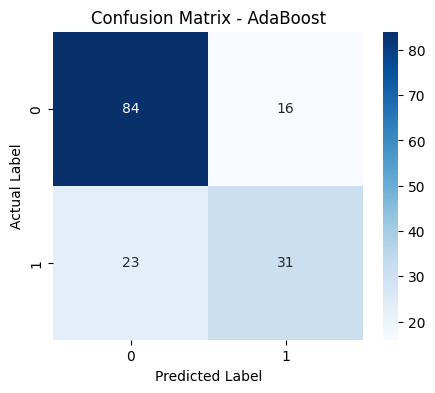

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Store all predictions
model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb,
    "Gradient Boosting": y_pred_gb,
    "AdaBoost": y_pred_ab
}

# Generate confusion matrix for each model
for name, y_pred in model_predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

###ROC Curve

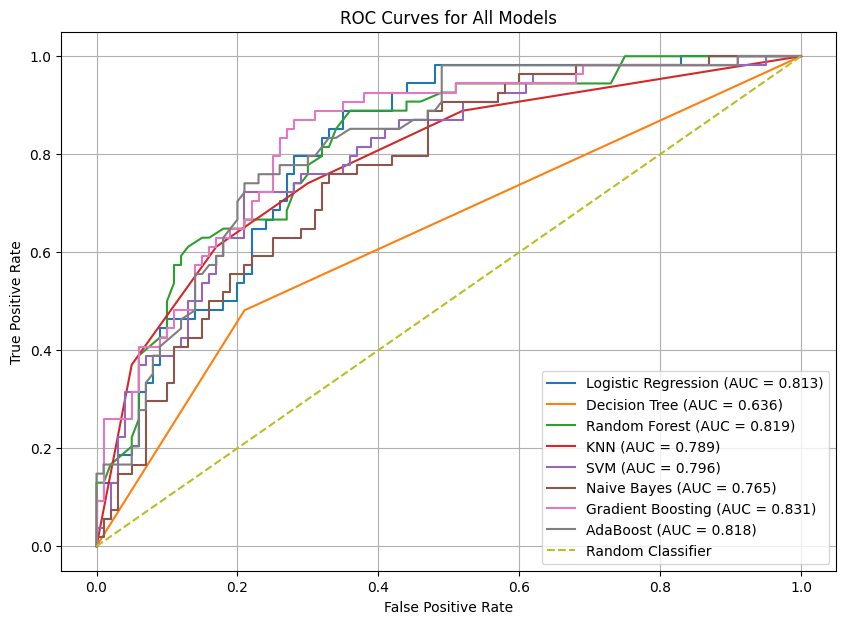

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Models and their corresponding test data
models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Decision Tree": (decision_tree, X_test),
    "Random Forest": (random_forest, X_test),
    "KNN": (knn, X_test_scaled),
    "SVM": (svm, X_test_scaled),
    "Naive Bayes": (naive_bayes, X_test),
    "Gradient Boosting": (gradient_boosting, X_test),
    "AdaBoost": (adaboost, X_test)
}

roc_auc_results = {}

plt.figure(figsize=(10, 7))

for name, (model, test_data) in models.items():

    # Get probability/score
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(test_data)[:, 1]

    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(test_data)

    else:
        print(f"ROC-AUC not available for {name}")
        continue

    # Calculate ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_score)

    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_score)

    roc_auc_results[name] = auc_score

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.grid()
plt.show()

 ### ROC-AUC Comparision Table


In [ ]:
roc_auc_df = pd.DataFrame(
    list(roc_auc_results.items()),
    columns=["Model", "ROC-AUC"]
)

roc_auc_df = roc_auc_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

roc_auc_df

,Model,ROC-AUC
6,Gradient Boosting,0.831481
2,Random Forest,0.819167
7,AdaBoost,0.817963
0,Logistic Regression,0.812963
4,SVM,0.796296
3,KNN,0.788611
5,Naive Bayes,0.764630
1,Decision Tree,0.635741


### Final Model Comparison

In [ ]:
# Combine the evaluation results with ROC-AUC
final_results = results_df.merge(roc_auc_df, on="Model")

# Sort models based on F1-Score
final_results = final_results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("FINAL MODEL COMPARISON")
display(final_results)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.779221,0.774498,0.779221,0.773213,0.819167
1,Gradient Boosting,0.759740,0.753890,0.759740,0.753992,0.831481
2,KNN,0.753247,0.749660,0.753247,0.750921,0.788611
3,AdaBoost,0.746753,0.741050,0.746753,0.742259,0.817963
4,SVM,0.740260,0.733735,0.740260,0.734865,0.796296
5,Naive Bayes,0.701299,0.709892,0.701299,0.704540,0.764630
6,Logistic Regression,0.707792,0.698892,0.707792,0.700802,0.812963
7,Decision Tree,0.681818,0.673403,0.681818,0.676172,0.635741


### Final Model Comparision as Percentage

In [ ]:
# Display metrics as percentages

final_results_display = final_results.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

final_results_display[metric_columns] = (
    final_results_display[metric_columns] * 100
)

display(final_results_display.round(2))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,77.92,77.45,77.92,77.32,81.92
1,Gradient Boosting,75.97,75.39,75.97,75.40,83.15
2,KNN,75.32,74.97,75.32,75.09,78.86
3,AdaBoost,74.68,74.10,74.68,74.23,81.80
4,SVM,74.03,73.37,74.03,73.49,79.63
5,Naive Bayes,70.13,70.99,70.13,70.45,76.46
6,Logistic Regression,70.78,69.89,70.78,70.08,81.30
7,Decision Tree,68.18,67.34,68.18,67.62,63.57


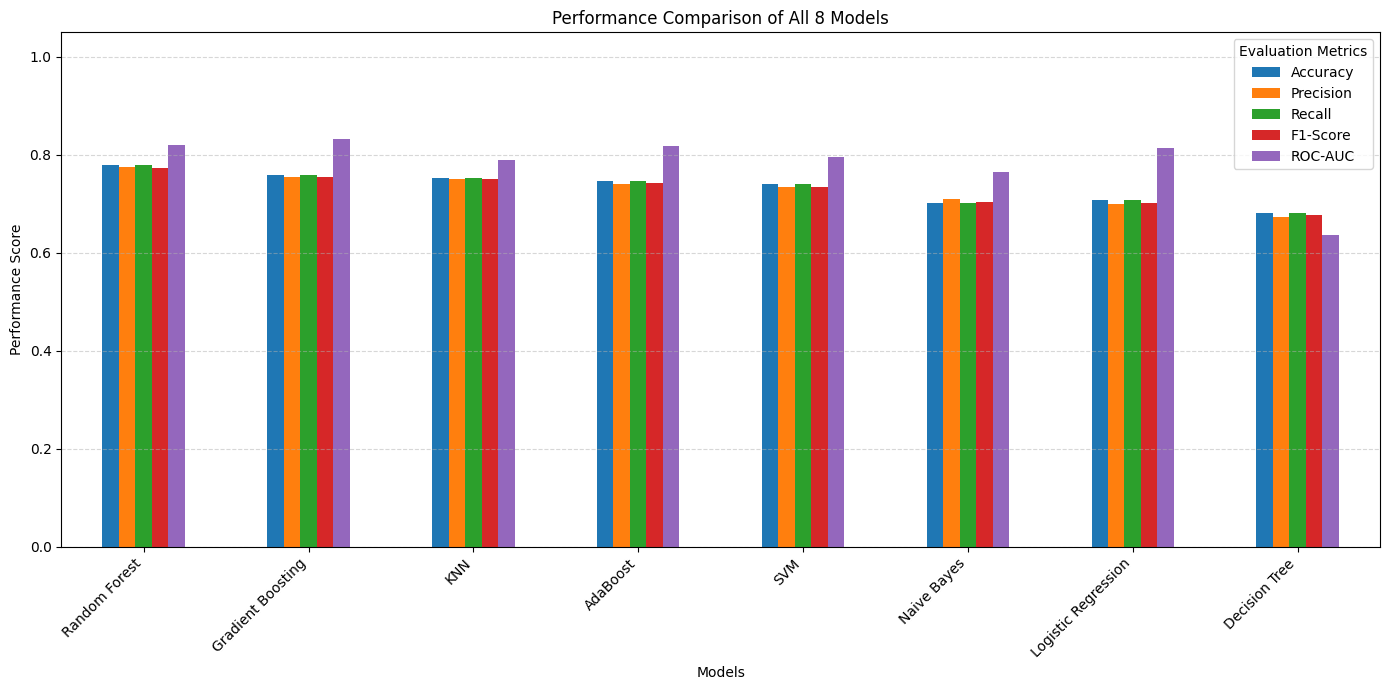

In [ ]:
import matplotlib.pyplot as plt

# Use the final results table
plot_df = final_results.set_index("Model")

# Plot all evaluation metrics
plot_df[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Performance Comparison of All 8 Models")
plt.xlabel("Models")
plt.ylabel("Performance Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Evaluation Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Accuracy Comparison Graph

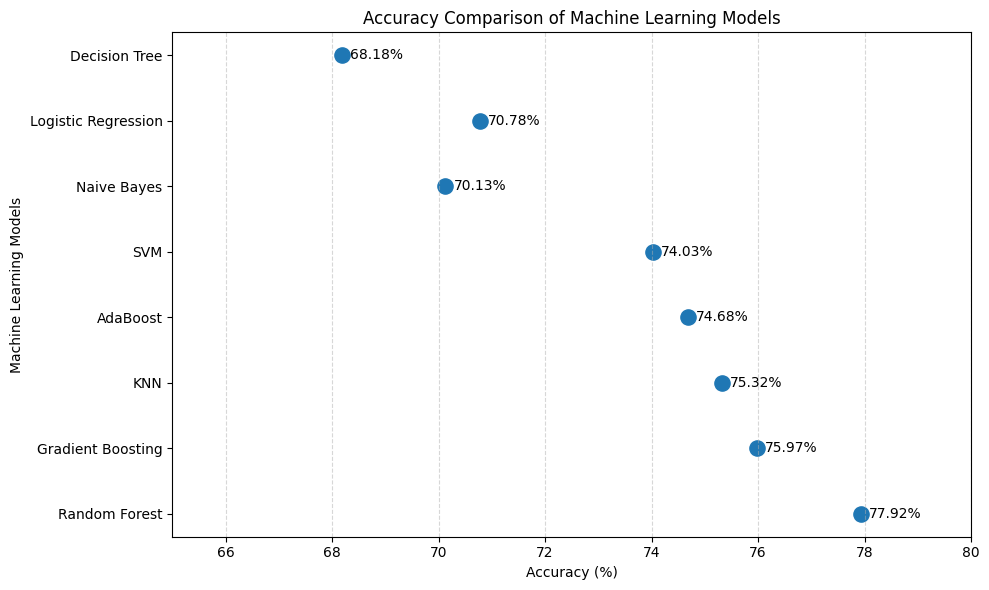

In [ ]:
import matplotlib.pyplot as plt

models = final_results["Model"]
accuracy = final_results["Accuracy"] * 100

plt.figure(figsize=(10, 6))

plt.scatter(accuracy, models, s=120)

for i, value in enumerate(accuracy):
    plt.text(value + 0.15, i, f"{value:.2f}%", va="center")

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Models")

# Zoom the axis to clearly show small differences
plt.xlim(65, 80)

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Overall Performance Comparison

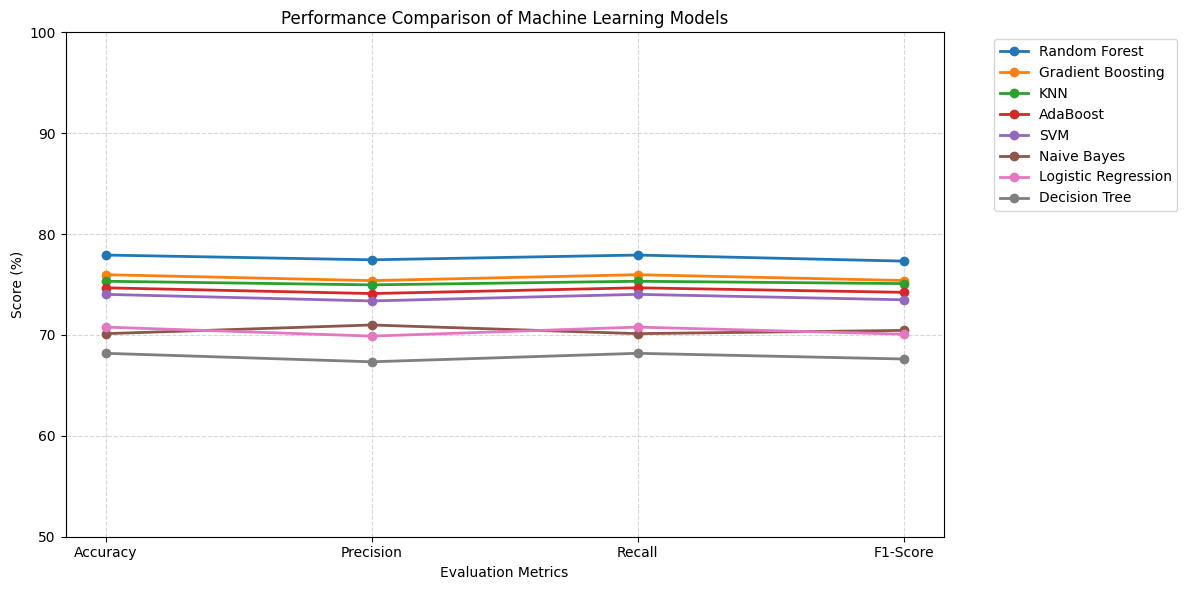

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

plt.figure(figsize=(12, 6))

for model in final_results["Model"]:
    row = final_results[final_results["Model"] == model].iloc[0]
    values = [row[metric] * 100 for metric in metrics]
    plt.plot(metrics, values, marker='o', linewidth=2, label=model)

plt.title("Performance Comparison of Machine Learning Models")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score (%)")
plt.ylim(50, 100)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ROC-AUC Comparison

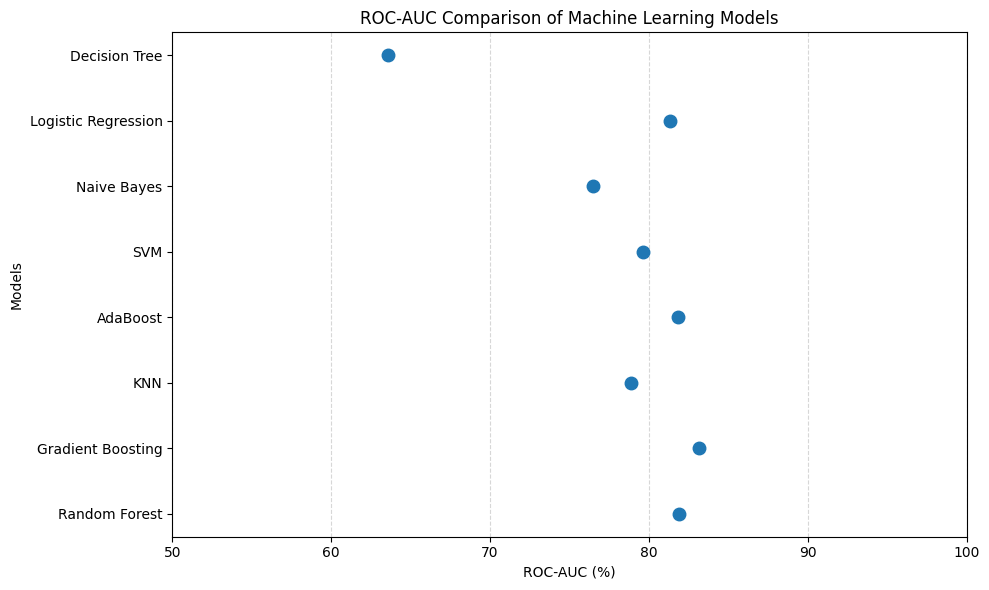

In [ ]:
import matplotlib.pyplot as plt

models = final_results["Model"]
roc_auc = final_results["ROC-AUC"] * 100

plt.figure(figsize=(10, 6))
plt.plot(roc_auc, models, "o", markersize=9)
plt.title("ROC-AUC Comparison of Machine Learning Models")
plt.xlabel("ROC-AUC (%)")
plt.ylabel("Models")
plt.xlim(50, 100)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Best Model Selection

In [ ]:
best_model = final_results.loc[
    final_results["F1-Score"].idxmax(), "Model"
]

print("Best Overall Model:", best_model)
print("Reason: It provides the best overall balance of Accuracy, Precision, Recall, and F1-Score.")

Best Overall Model: Random Forest
Reason: It provides the best overall balance of Accuracy, Precision, Recall, and F1-Score.


### Final Analysis

Random Forest achieved the best overall performance among the eight machine learning models based on Accuracy, Precision, Recall, and F1-Score. Therefore, Random Forest was selected as the final model for diabetes prediction.

Gradient Boosting achieved the highest ROC-AUC score, indicating strong class-separation ability. However, Random Forest provided the most balanced overall performance and was selected as the final model.